![Py4Eng](../logo.png)
# Convolutional Neural Networks with PyTorch
## Yoav Ram

In this session we will understand:
- how convolutional networks process images
- how to build and train a CNN in PyTorch on MNIST


We reuse the setup from the FFN session:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(0)
print("Torch:", torch.__version__, "Device:", device)


Torch: 2.7.1 Device: mps


In [2]:
transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

batch_size = 50
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

nchannels = 1
ncats = 10

In [3]:
def accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


def train_one_batch(model, xb, yb, optimizer, loss_fn):
    model.train()
    xb, yb = xb.to(device), yb.to(device)
    optimizer.zero_grad()
    logits = model(xb)
    loss = loss_fn(logits, yb)
    loss.backward()
    optimizer.step()
    return loss.item(), accuracy(logits, yb)


def evaluate(model, loader, loss_fn):
    model.eval()
    running_loss, running_acc, batches = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            running_loss += loss.item()
            running_acc += accuracy(logits, yb)
            batches += 1
    return running_loss / batches, running_acc / batches

# Multilayer Convolutional Network

We build a multilayer convolutional neuron network.

In a convolutional neural network we replace some of the fully-connected layers with convolutional layers in which we apply several convolutional filters to the input.

See this [animation of convolutions](http://cs231n.github.io/assets/conv-demo/index.html).

A convolution is very efficient because parameters of the convolution are shared among all pixels, and the convolution is robust to the position of a feature inside the image.

We'll start by implementing a two-layer network in which the first layer is a convolutional layer and the second layer is a fully-connected softmax layer:
$$
z^{(1)} = W^{(1)} \ast x^{(1)} + b^{(1)} $$$$
x^{(2)} = \text{pool}(\text{ReLU}(z^{(1)})) $$
$$
z^{(2)} = W^{(2)} \ast x^{(2)} + b^{(2)} $$$$
x^{(3)} = \text{pool}(\text{ReLU}(z^{(2)})) $$
$$
z^{(3)} = W^{(3)} \cdot x^{(3)} + b^{(3)} $$$$
x^{(4)} = \text{ReLU}(z^{(3)}) $$
$$
z^{(4)} = W^{(4)} \cdot x^{(4)} + b^{(4)} $$$$
\hat{y} = \text{softmax}(z^{(4)}) $$
$$

![](https://user-images.githubusercontent.com/15166794/39059111-a0b15a90-44f8-11e8-98a8-242bc9d80428.png)

Convolutional nets replace early fully connected layers with local convolutions and pooling. Inputs are 4D tensors `(batch, channels, height, width)`; here `channels=1` for grayscale MNIST. Convolutions learn spatial filters, ReLU keeps positive activations, and pooling downsamples to make features more translation-robust before a dense head.

## 1st Convolutional layer

The first convolutional layer is generated by a convolution with 1 input channel, 32 output channgels, and 5x5 kernels.

The convolution computes 32 features of 5x5 patches; it returns a tensor with shape `(-1, 24, 24, 32)`; 2 pixels are lost from the boundaries.

We then apply a ReLu activation function ($f(x)=max(0,x)$).

## Pooling

The new element here is the $pool$ function, which applies **pooling** - the combination of several neurons/pixels into a single one.

We will use a common pooling approach called *2x2 max pooling* in which every 2x2 square of pixels is replaced by its maximal value.

![](https://upload.wikimedia.org/wikipedia/commons/e/e9/Max_pooling.png)

Pooling adds another non-linear component, reduces the size of the layers, and thus the number of paramters, and reduces over-fitting by approximating the location of feautures.

Since thd activation function operates element-wise without impacting the shape, the output of the activation and pooling has shape `(-1, 12, 12, 32)`.

## 2nd Convolutional layer

We add another convolution + pooling layer, the 2nd layer will have 64 features. The input has 32 channels (from the previous 32 features) but the data arrays are smaller (12x12) due to the previous pooling. The data is now is shape `(-1, 4, 4, 64)`.

## Linear layer 
After the convolutions local patterns with shared weights, a linear layer connects them to a dense representation of the image. But first we need to flatten the input from 4x4x64 to 1,024; then we create a dense layer that connets these 1,024 neurons to the next 1,024 neurons.

## Dropout
We apply a dropout to reduce overfitting: the dropout stochasticly removes neurons (outputs of the previous layer) and automatically scales the neurons it retained so that their expected sum remains unchanged.

## Classifier head
Finally, a softmax layer converts the output to a probability distribution over classes.


In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(64 * 4 * 4, 1024)
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(1024, ncats)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = F.relu(self.linear(x))
        x = self.dropout(x)
        return self.classifier(x) 

# Train the model

Training works the same as with FFN.

In [11]:
model = CNN().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [12]:
metrics = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
epochs = 5

train_loss, train_acc = evaluate(model, train_loader, loss_fn)
val_loss, val_acc = evaluate(model, test_loader, loss_fn)
metrics["train_loss"].append(train_loss)
metrics["train_accuracy"].append(train_acc)
metrics["val_loss"].append(val_loss)
metrics["val_accuracy"].append(val_acc)
print(f"Epoch 0: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

Epoch 0: train_acc=0.128, val_acc=0.133


In [13]:
for epoch in range(epochs):
    for xb, yb in train_loader:
        train_one_batch(model, xb, yb, optimizer, loss_fn)
    train_loss, train_acc = evaluate(model, train_loader, loss_fn)
    val_loss, val_acc = evaluate(model, test_loader, loss_fn)
    metrics["train_loss"].append(train_loss)
    metrics["train_accuracy"].append(train_acc)
    metrics["val_loss"].append(val_loss)
    metrics["val_accuracy"].append(val_acc)
    print(f"Epoch {epoch+1:02d}: train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, val_loss={val_loss:.4f},  val_acc={val_acc:.3f}")

Epoch 01: train_loss=0.0478, train_acc=0.985, val_loss=0.0468,  val_acc=0.984
Epoch 02: train_loss=0.0298, train_acc=0.992, val_loss=0.0376,  val_acc=0.988
Epoch 03: train_loss=0.0138, train_acc=0.996, val_loss=0.0239,  val_acc=0.993
Epoch 04: train_loss=0.0113, train_acc=0.997, val_loss=0.0286,  val_acc=0.992
Epoch 05: train_loss=0.0089, train_acc=0.997, val_loss=0.0271,  val_acc=0.992


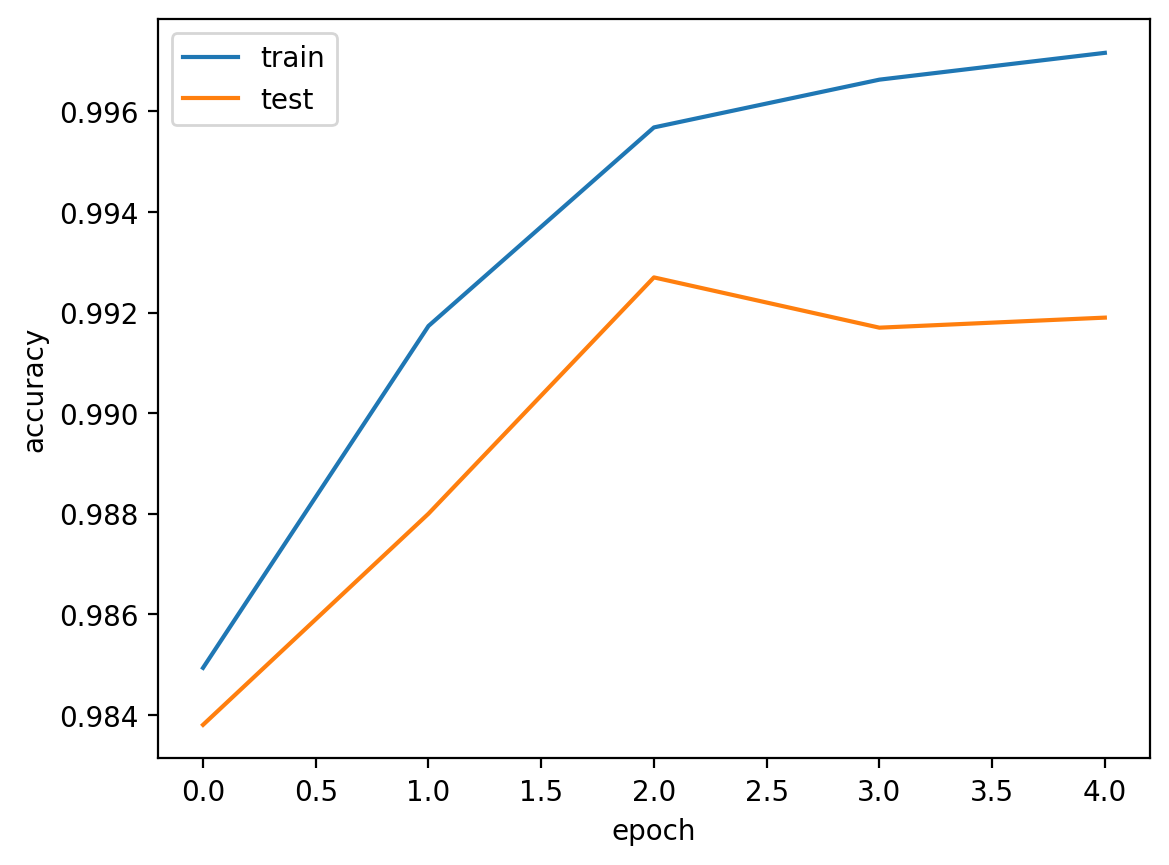

Epoch 02: train_acc=0.992, val_acc=0.987


Epoch 03: train_acc=0.995, val_acc=0.991


Epoch 04: train_acc=0.996, val_acc=0.991


Epoch 05: train_acc=0.996, val_acc=0.993


Epoch 06: train_acc=0.995, val_acc=0.990


...

Epoch 16: train_acc=0.999, val_acc=0.992


Epoch 17: train_acc=0.999, val_acc=0.991


Epoch 18: train_acc=0.999, val_acc=0.991


Epoch 19: train_acc=0.999, val_acc=0.991


Epoch 20: train_acc=1.000, val_acc=0.993


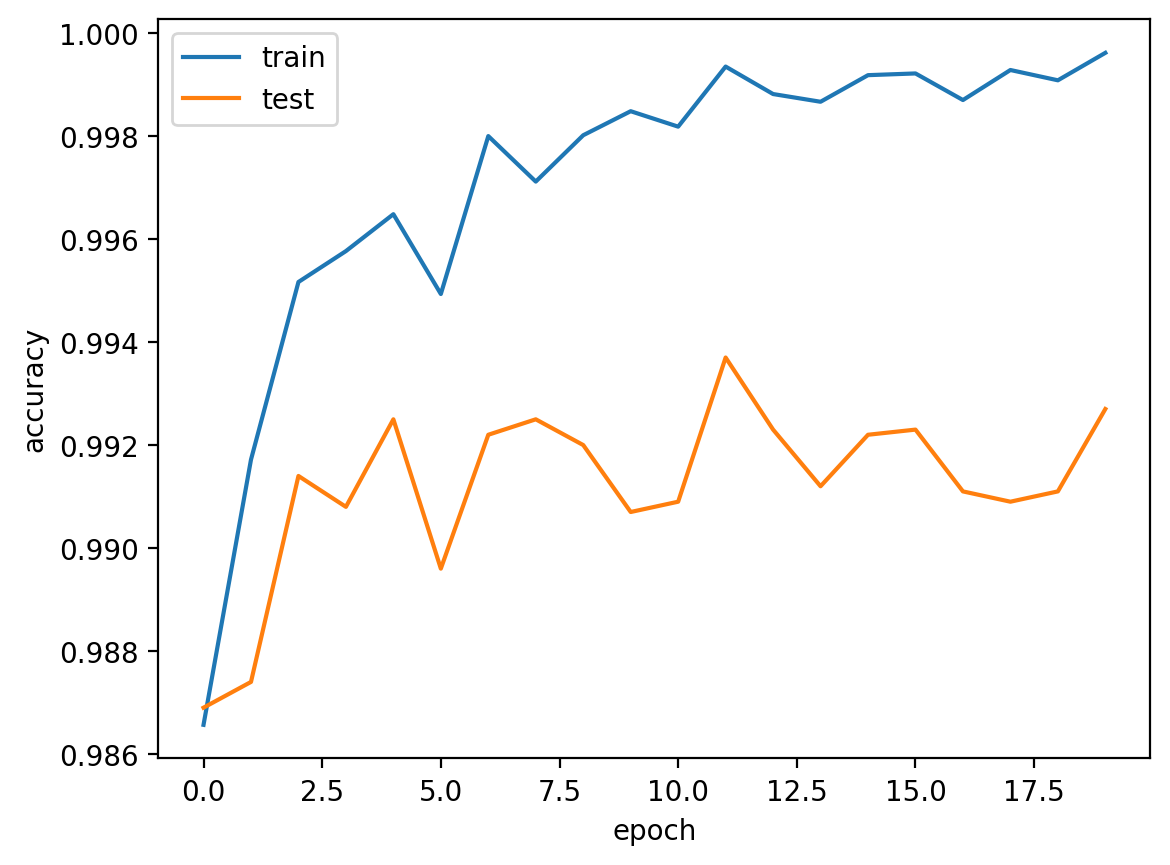

In [14]:
plt.plot(metrics['train_accuracy'][1:], label='train')
plt.plot(metrics['val_accuracy'][1:], label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend();

Save the model and training history:


In [15]:
torch.save(model.state_dict(), "../data/torch_cnn_state.pt")
torch.save(metrics, "../data/torch_cnn_history.pt")

Load the model and history:


In [16]:
model = CNN().to(device)
model.load_state_dict(torch.load("../data/torch_cnn_state.pt", map_location=device))
metrics = torch.load("../data/torch_cnn_history.pt")

Predict on a test image:


In [18]:
model.eval()
im, label = test_ds[0]
with torch.no_grad():
    logits = model(im.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).cpu().squeeze()
print(f"Truth: {label}, Prediction: {probs.argmax().item()} ({probs.max():.4f})")

Truth: 7, Prediction: 7 (1.0000)


# References
- [PyTorch docs](https://pytorch.org)
- [TorchVision docs](https://pytorch.org/vision/stable/index.html)
- [Stanford's CS231n](https://cs231n.github.io/convolutional-networks/) for a brief introduction
- [Deep Learning by Ian Goodfellow and Yoshua Bengio and Aaron Courville](http://www.deeplearningbook.org), ch. 9, for a comprehensive introduction.
- [Quiver](https://keplr-io.github.io/quiver/) can visualize the network weights.
- [Shap](https://github.com/slundberg/shap): A game theoretic approach to explain the output of any machine learning model.
- [Visualization of CNN on MNIST](https://adamharley.com/nn_vis/cnn/3d.html)
- [Visualizing what ConvNets learn](https://cs231n.github.io/understanding-cnn/)

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).
This work is licensed under a CC BY-NC-SA 4.0 International License.
![Python logo](../logo.png)
